<a href="https://colab.research.google.com/github/NK47GG/image-similarity/blob/main/Image_Similarity_with_Autoencoder_PKAC_FIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visually Similar Product Recommendation
**Architecture**: Convolutional Autoencoder + Cosine Similarity  
**Dataset**: `paramaggarwal/fashion-product-images-dataset`

### Pipeline
1. Data Collection & Preprocessing
2. Model Architecture — Convolutional Autoencoder
3. Training
4. Feature Extraction (Encoder only)
5. Inference — Cosine Similarity Search

## 0. Environment Setup

In [17]:
import kagglehub
dataset_path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")
print("Dataset path:", dataset_path)

Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Dataset path: /kaggle/input/fashion-product-images-dataset


In [18]:
import os
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Reshape,
    Conv2DTranspose, UpSampling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics.pairwise import cosine_similarity

IMG_SIZE   = (128, 128)
IMG_SHAPE  = (128, 128, 3)
BATCH_SIZE = 32
LATENT_DIM = 256
EPOCHS     = 50

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 1. Data Collection & Preprocessing

**Perubahan dari versi sebelumnya:**
- ✅ Filter `articleType == 'Shirts'` (lebih granular vs `subCategory`)
- ✅ Sample maks. **1.000 baris** dengan `random_state=42`
- ✅ Split **Train 70% / Val 15% / Test 15%** → tiga DataFrame terpisah
- ✅ Inisialisasi `test_generator` dengan `shuffle=False`

In [19]:
# ── 1.1  Load CSV ─────────────────────────────────────────────
# images.csv  : mapping id → filename
# styles.csv  : metadata produk (articleType, subCategory, dll.)
images_df = pd.read_csv(
    os.path.join(dataset_path, "fashion-dataset", "images.csv")
)
styles_df = pd.read_csv(
    os.path.join(dataset_path, "fashion-dataset", "styles.csv"),
    on_bad_lines="skip"
)

# Samakan tipe kolom 'id' agar merge tidak error
images_df["id"] = images_df["filename"].str.replace(".jpg", "", regex=False).astype(int)

print(f"images_df : {images_df.shape}")
print(f"styles_df : {styles_df.shape}")
print(f"\nNilai unik articleType (top-10):\n{styles_df['articleType'].value_counts().head(10)}")

images_df : (44446, 3)
styles_df : (44424, 10)

Nilai unik articleType (top-10):
articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Name: count, dtype: int64


In [20]:
# ── 1.2  Filter hanya "Shirts" ────────────────────────────────
# Kolom `articleType` dipakai karena lebih granular dibanding
# `subCategory` (mis. subCategory="Topwear" mencakup banyak jenis).
shirts_df = styles_df[styles_df["articleType"] == "Shirts"].reset_index(drop=True)

print(f"Total produk 'Shirts' ditemukan : {len(shirts_df):,} baris")

Total produk 'Shirts' ditemukan : 3,217 baris


In [21]:
# ── 1.3  Batasi maksimal 1.000 baris ─────────────────────────
# min() memastikan tidak error jika total Shirts < 1000.
# random_state=42 menjamin hasil reproducible di setiap run.
shirts_df = shirts_df.sample(n=min(1000, len(shirts_df)), random_state=42).reset_index(drop=True)

print(f"Ukuran dataset setelah sampling  : {len(shirts_df):,} baris")

Ukuran dataset setelah sampling  : 1,000 baris


In [22]:
# ── 1.4  Merge dengan images_df & validasi file ───────────────
images_dir  = os.path.join(dataset_path, "fashion-dataset", "images")
image_files = set(os.listdir(images_dir))

data = shirts_df.merge(images_df, on="id", how="left").reset_index(drop=True)
data["filename"]   = data["filename"].apply(lambda x: os.path.join(images_dir, x))
data["file_found"] = data["id"].apply(lambda x: f"{x}.jpg" in image_files)

# Buang baris yang file gambarnya tidak tersedia di disk
data = data[data["file_found"]].reset_index(drop=True)
data.drop(columns=["productDisplayName", "link", "file_found"], inplace=True, errors="ignore")

print(f"Dataset setelah validasi file    : {data.shape}")
data.head()

Dataset setelah validasi file    : (1000, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,filename
0,8859,Men,Apparel,Topwear,Shirts,White,Fall,2011.0,Casual,/kaggle/input/fashion-product-images-dataset/f...
1,18889,Women,Apparel,Topwear,Shirts,Blue,Fall,2011.0,Formal,/kaggle/input/fashion-product-images-dataset/f...
2,8181,Men,Apparel,Topwear,Shirts,Purple,Summer,2011.0,Casual,/kaggle/input/fashion-product-images-dataset/f...
3,5960,Men,Apparel,Topwear,Shirts,Purple,Summer,2011.0,Casual,/kaggle/input/fashion-product-images-dataset/f...
4,13734,Men,Apparel,Topwear,Shirts,Blue,Fall,2011.0,Casual,/kaggle/input/fashion-product-images-dataset/f...


In [23]:
# ── 1.5  Train / Val / Test Split  (70 / 15 / 15) ────────────
# Shuffle seluruh data sebelum split agar distribusi merata.
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

n         = len(data)
train_end = int(n * 0.70)   # cutoff 70 %
val_end   = int(n * 0.85)   # cutoff 85 %  (70 + 15)

train = data.iloc[:train_end].reset_index(drop=True)          # 70 %
val   = data.iloc[train_end:val_end].reset_index(drop=True)   # 15 %
test  = data.iloc[val_end:].reset_index(drop=True)            # 15 % sisanya

print(f"Train : {len(train):>4} samples  ({len(train)/n*100:.1f}%)")
print(f"Val   : {len(val):>4} samples  ({len(val)/n*100:.1f}%)")
print(f"Test  : {len(test):>4} samples  ({len(test)/n*100:.1f}%)")

Train :  700 samples  (70.0%)
Val   :  150 samples  (15.0%)
Test  :  150 samples  (15.0%)


In [24]:
# ── 1.6  ImageDataGenerator ───────────────────────────────────
# Satu datagen shared untuk ketiga split; hanya rescale karena
# autoencoder tidak membutuhkan augmentasi gambar.
datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# — Train: shuffle=True agar urutan batch bervariasi tiap epoch
train_generator = datagen.flow_from_dataframe(
    dataframe  = train,
    x_col      = "filename",
    y_col      = "filename",
    target_size= IMG_SIZE,
    class_mode = "input",
    batch_size = BATCH_SIZE,
    shuffle    = True,
)

# — Val: shuffle=False agar val_loss per-epoch konsisten & comparable
val_generator = datagen.flow_from_dataframe(
    dataframe  = val,
    x_col      = "filename",
    y_col      = "filename",
    target_size= IMG_SIZE,
    class_mode = "input",
    batch_size = BATCH_SIZE,
    shuffle    = False,   # ← wajib False untuk evaluasi
)

# — Test: shuffle=False agar urutan prediksi ↔ metadata sinkron
test_generator = datagen.flow_from_dataframe(
    dataframe  = test,
    x_col      = "filename",
    y_col      = "filename",
    target_size= IMG_SIZE,
    class_mode = "input",
    batch_size = BATCH_SIZE,
    shuffle    = False,   # ← wajib False untuk evaluasi & inferensi
)

print("\nGenerator siap:")
print(f"  train_generator : {train_generator.n} gambar")
print(f"  val_generator   : {val_generator.n} gambar")
print(f"  test_generator  : {test_generator.n} gambar")

Found 700 validated image filenames.
Found 150 validated image filenames.
Found 150 validated image filenames.

Generator siap:
  train_generator : 700 gambar
  val_generator   : 150 gambar
  test_generator  : 150 gambar


## 2. Model Architecture — Convolutional Autoencoder

```
Input (128×128×3)
    │
    ▼  ── ENCODER ──────────────────────────────────
Conv2D(32)  → MaxPool  →  (64×64×32)
Conv2D(64)  → MaxPool  →  (32×32×64)
Conv2D(128) → MaxPool  →  (16×16×128)
Conv2D(256) → MaxPool  →  (8×8×256)
Flatten → Dense(256)   →  Latent Space ✦
    │
    ▼  ── DECODER ──────────────────────────────────
Dense → Reshape (8×8×256)
UpSampling → Conv2DTranspose(256) → (16×16×256)
UpSampling → Conv2DTranspose(128) → (32×32×128)
UpSampling → Conv2DTranspose(64)  → (64×64×64)
UpSampling → Conv2DTranspose(3)   → (128×128×3)
```

In [25]:
def build_autoencoder(input_shape=IMG_SHAPE, latent_dim=LATENT_DIM):
    inputs = Input(shape=input_shape, name="encoder_input")

    # ── Encoder ──────────────────────────────────────────────
    x = Conv2D(32,  (3, 3), activation="relu", padding="same")(inputs)
    x = MaxPooling2D((2, 2), padding="same")(x)

    x = Conv2D(64,  (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2), padding="same")(x)

    x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2), padding="same")(x)

    x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2), padding="same")(x)

    conv_shape = x.shape[1:]
    x = Flatten()(x)
    encoded = Dense(latent_dim, activation="relu", name="latent_space")(x)

    # ── Decoder ──────────────────────────────────────────────
    x = Dense(conv_shape[0] * conv_shape[1] * conv_shape[2], activation="relu")(encoded)
    x = Reshape(conv_shape)(x)

    x = UpSampling2D((2, 2))(x)
    x = Conv2DTranspose(256, (3, 3), activation="relu", padding="same")(x)

    x = UpSampling2D((2, 2))(x)
    x = Conv2DTranspose(128, (3, 3), activation="relu", padding="same")(x)

    x = UpSampling2D((2, 2))(x)
    x = Conv2DTranspose(64,  (3, 3), activation="relu", padding="same")(x)

    x = UpSampling2D((2, 2))(x)
    decoded = Conv2DTranspose(3, (3, 3), activation="sigmoid", padding="same", name="decoder_output")(x)

    autoencoder = Model(inputs, decoded,  name="autoencoder")
    encoder     = Model(inputs, encoded,  name="encoder")
    return autoencoder, encoder


autoencoder, encoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16384)          │     4,210,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 128, 128, 3)    │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,754,307 (37.21 MB)

 Trainable params: 9,754,307 (37.21 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [10]:
autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("encoder_weights.h5", monitor="val_loss", save_best_only=True, verbose=1),
]

history = autoencoder.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0967
Epoch 1: val_loss improved from None to 0.04510, saving model to encoder_weights.h5



Epoch 1: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - loss: 0.0675 - val_loss: 0.0451
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - loss: 0.0457
Epoch 2: val_loss improved from 0.04510 to 0.03992, saving model to encoder_weights.h5



Epoch 2: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 972ms/step - loss: 0.0437 - val_loss: 0.0399
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - loss: 0.0385
Epoch 3: val_loss improved from 0.03992 to 0.03210, saving model to encoder_weights.h5



Epoch 3: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 875ms/step - loss: 0.0365 - val_loss: 0.0321
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - loss: 0.0300
Epoch 4: val_loss improved from 0.03210 to 0.02869, saving model to encoder_weights.h5



Epoch 4: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 934ms/step - loss: 0.0291 - val_loss: 0.0287
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - loss: 0.0271
Epoch 5: val_loss improved from 0.02869 to 0.02641, saving model to encoder_weights.h5


...


Epoch 33: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 884ms/step - loss: 0.0126 - val_loss: 0.0168
Epoch 34/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - loss: 0.0128
Epoch 34: val_loss did not improve from 0.01681
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 919ms/step - loss: 0.0124 - val_loss: 0.0169
Epoch 35/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - loss: 0.0124
Epoch 35: val_loss did not improve from 0.01681
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 902ms/step - loss: 0.0122 - val_loss: 0.0168
Epoch 36/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - loss: 0.0118
Epoch 36: val_loss improved from 0.01681 to 0.01674, saving model to encoder_weights.h5



Epoch 36: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 888ms/step - loss: 0.0120 - val_loss: 0.0167
Epoch 37/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - loss: 0.0123
Epoch 37: val_loss improved from 0.01674 to 0.01666, saving model to encoder_weights.h5



Epoch 37: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 953ms/step - loss: 0.0118 - val_loss: 0.0167
Epoch 38/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - loss: 0.0111
Epoch 38: val_loss did not improve from 0.01666
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 877ms/step - loss: 0.0116 - val_loss: 0.0167
Epoch 39/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - loss: 0.0113
Epoch 39: val_loss improved from 0.01666 to 0.01664, saving model to encoder_weights.h5



Epoch 39: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 893ms/step - loss: 0.0115 - val_loss: 0.0166
Epoch 40/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - loss: 0.0114
Epoch 40: val_loss improved from 0.01664 to 0.01663, saving model to encoder_weights.h5



Epoch 40: finished saving model to encoder_weights.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 863ms/step - loss: 0.0114 - val_loss: 0.0166
Epoch 41/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - loss: 0.0110
Epoch 41: val_loss did not improve from 0.01663
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 870ms/step - loss: 0.0113 - val_loss: 0.0168
Epoch 42/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - loss: 0.0110
Epoch 42: val_loss did not improve from 0.01663
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 853ms/step - loss: 0.0113 - val_loss: 0.0167
Epoch 43/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - loss: 0.0108
Epoch 43: val_loss did not improve from 0.01663
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 884ms/step - loss: 0.0111 - val_loss: 0.0168
Epoch 44/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - loss: 0.0112
Epoch 44: val_loss did not improve from 0.01663
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 876ms/step - loss: 0.0111 - val_loss: 0.0167
Epoch 45/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - loss: 0.0111
Epoch 45: val_loss did not improv

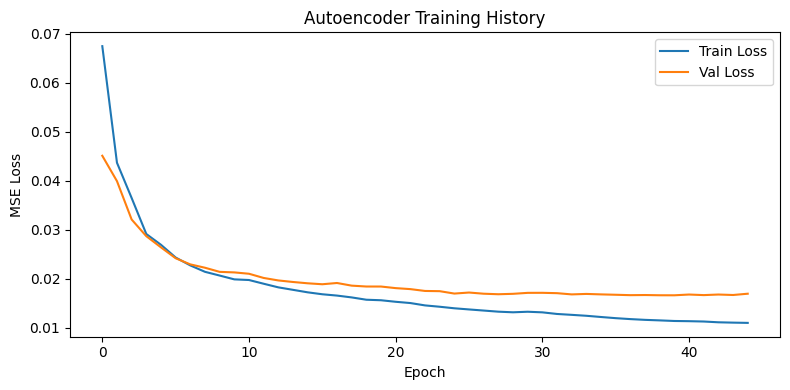

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Feature Extraction
Setelah training selesai, Decoder dibuang. Hanya Encoder yang dipakai untuk menghasilkan embeddings dari seluruh **test set**.
Embeddings dan metadata (`id` + `filename`) dikemas bersama ke dalam **satu file** `database.pkl` menggunakan `joblib`.

```
database.pkl
├── embeddings  →  numpy array (N, 256)
└── metadata    →  DataFrame  (N, 2)  [id, filename]
```

> **Catatan**: Feature extraction kini menggunakan `test` (bukan `val`) agar database dibangun dari data yang belum pernah dilihat model selama training.

In [12]:
import joblib

# Gunakan test_generator (shuffle=False) — data belum pernah dilihat model
feature_generator = datagen.flow_from_dataframe(
    dataframe  = test,
    x_col      = "filename",
    target_size= IMG_SIZE,
    class_mode = None,
    batch_size = BATCH_SIZE,
    shuffle    = False,
)

embeddings = encoder.predict(feature_generator, verbose=1)

database = {
    "embeddings": embeddings,
    "metadata"  : test[["id", "filename"]].reset_index(drop=True),
}
joblib.dump(database, "database.pkl")

print(f"Embeddings shape : {embeddings.shape}")
print(f"Metadata rows    : {len(database['metadata'])}")
print("Saved → database.pkl | encoder_weights.h5")

Found 150 validated image filenames.
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 952ms/step
Embeddings shape : (150, 256)
Metadata rows    : 150
Saved → database.pkl | encoder_weights.h5


In [13]:
# ── Download artefak ke lokal (khusus Google Colab) ───────────
import shutil, os

DUMP_DIR = "streamlit_artifacts"
os.makedirs(DUMP_DIR, exist_ok=True)

# Salin artefak ke folder dump
shutil.copy("database.pkl",        os.path.join(DUMP_DIR, "database.pkl"))
shutil.copy("encoder_weights.h5",  os.path.join(DUMP_DIR, "encoder_weights.h5"))

print("📦 Isi folder artefak:")
for f in os.listdir(DUMP_DIR):
    size_mb = os.path.getsize(os.path.join(DUMP_DIR, f)) / 1e6
    print(f"   {f:<30} {size_mb:.2f} MB")

try:
    from google.colab import files
    zip_path = shutil.make_archive("streamlit_artifacts", "zip", DUMP_DIR)
    files.download(zip_path)
    print("\n✅ streamlit_artifacts.zip sedang diunduh...")
except ImportError:
    print("\nℹ️  Bukan environment Colab — salin folder 'streamlit_artifacts/' secara manual.")

📦 Isi folder artefak:
   database.pkl                   0.17 MB
   encoder_weights.h5             117.14 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ streamlit_artifacts.zip sedang diunduh...


## 5. Inference — Cosine Similarity Search

In [14]:
def load_and_preprocess(image_path, target_size=IMG_SIZE):
    img = load_img(image_path, target_size=target_size)
    arr = img_to_array(img) / 255.0
    return np.expand_dims(arr, axis=0)


def find_similar_products(query_path, encoder_model, db_embeddings, db_df, top_k=5):
    query_input     = load_and_preprocess(query_path)
    query_embedding = encoder_model.predict(query_input, verbose=0)

    scores  = cosine_similarity(query_embedding, db_embeddings)[0]
    indices = np.argsort(scores)[::-1][:top_k]

    results = db_df.iloc[indices].copy().reset_index(drop=True)
    results["similarity_score"] = scores[indices]
    return results

In [15]:
import random

sample_idx   = random.randint(0, len(test) - 1)
sample_query = test.loc[sample_idx, "filename"]

results = find_similar_products(
    query_path    = sample_query,
    encoder_model = encoder,
    db_embeddings = embeddings,
    db_df         = test,
    top_k         = 5,
)

print("Top-5 Recommendations:")
results[["id", "filename", "similarity_score"]]

Top-5 Recommendations:


,id,filename,similarity_score
0,29664,/kaggle/input/fashion-product-images-dataset/f...,1.000000
1,29639,/kaggle/input/fashion-product-images-dataset/f...,0.931782
2,29278,/kaggle/input/fashion-product-images-dataset/f...,0.888741
3,29701,/kaggle/input/fashion-product-images-dataset/f...,0.787060
4,20177,/kaggle/input/fashion-product-images-dataset/f...,0.781045


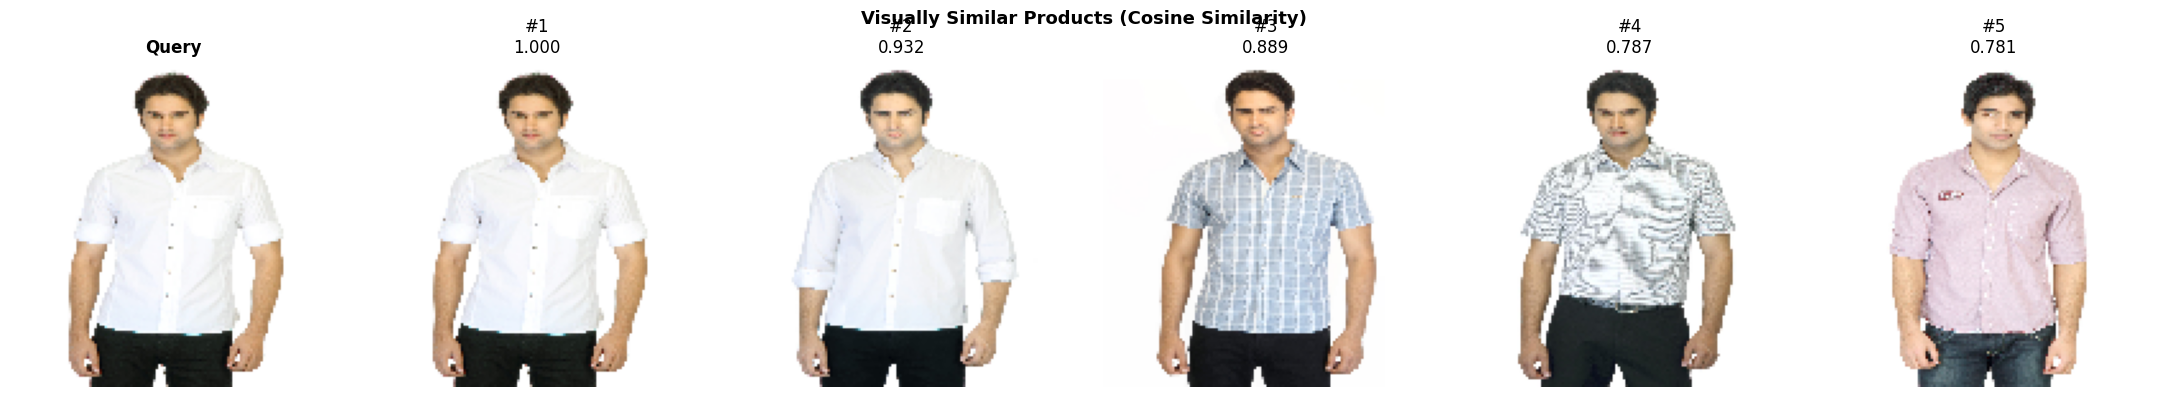

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(22, 4))

query_img = load_img(sample_query, target_size=IMG_SIZE)
axes[0].imshow(query_img)
axes[0].set_title("Query", fontweight="bold")
axes[0].axis("off")

for rank, (_, row) in enumerate(results.iterrows(), start=1):
    rec_img = load_img(row["filename"], target_size=IMG_SIZE)
    axes[rank].imshow(rec_img)
    axes[rank].set_title(f"#{rank}\n{row['similarity_score']:.3f}")
    axes[rank].axis("off")

plt.suptitle("Visually Similar Products (Cosine Similarity)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()